In [1]:
from utils import *
from model_utils import *
from visualizations import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import joblib

In [2]:
# datasets splits folder path
datasets_splits_folder_path = "../dataset/splits/v1"

In [3]:
# load label encoder
transformers_path = "./transfomers"
le = joblib.load(f"{transformers_path}/label_encoder.pkl")

In [4]:
X_train, y_train, X_dev, y_dev, X_test, y_test = load_data(datasets_splits_folder_path)

# check the shapes of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (20540, 42)
y_train shape: (20540,)
X_dev shape: (2567, 42)
y_dev shape: (2567,)
X_test shape: (2568, 42)
y_test shape: (2568,)


In [5]:
X_train[:5]

,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,...,x17,y17,x18,y18,x19,y19,x20,y20,x21,y21
0,159.707960,295.80722,167.253140,289.28845,171.947140,282.90234,173.94840,276.80420,175.16832,271.36984,...,159.45110,251.65263,154.265290,273.57693,154.33780,266.59882,154.39575,262.02438,154.41461,257.88693
1,111.113785,197.83873,115.414010,179.15083,126.650116,161.16145,134.29690,147.69128,134.56212,135.40723,...,152.41246,194.94882,148.141970,200.46864,165.40868,203.30000,175.78496,206.63016,184.82541,208.83627
2,111.572480,201.85477,118.025154,193.73083,118.788826,183.25960,111.06031,175.99445,102.39017,171.67297,...,106.48782,181.95824,99.176216,178.87938,96.92235,175.54149,100.71361,181.33572,103.96564,186.34886
3,134.884030,270.36010,146.096070,266.05374,156.054960,258.92340,163.19798,252.90840,164.89212,244.89627,...,146.16782,201.51768,127.770065,235.02124,126.77072,222.51634,127.75249,214.08505,129.67673,207.31053
4,100.787770,181.61578,118.487840,173.62929,134.799670,155.55620,138.00179,136.42476,130.78911,123.97259,...,104.67175,146.41678,88.961030,137.19592,93.54382,130.30640,96.08535,142.77351,94.42624,145.73808


In [6]:
y_train[:5]

0    12
1     0
2     9
3     6
4     2
Name: label, dtype: int64

In [7]:
# convert to numpy array
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

X_dev_np = X_dev.to_numpy()
y_dev_np = y_dev.to_numpy()

X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

## RandomForestClassifier

In [8]:
rf_model_name = "Random Forest Classifier"

# initialize RandomForestClassifier object
rf_model = RandomForestClassifier()

# initialize ModelTrainer object
rf_trainer = ModelTrainer(X_train_np, y_train_np)

# train rf_trainer object
rf_trainer.train(rf_model, rf_model_name)

# evaluate rf_model on datasets
rf_trainer.evaluate_and_store(rf_model_name, X_train_np, y_train_np, "train set")
rf_trainer.evaluate_and_store(rf_model_name, X_dev_np, y_dev_np, "development set")
rf_trainer.evaluate_and_store(rf_model_name, X_test_np, y_test_np, "test set")

# print out the metrics
rf_trainer.print_results("train set")
rf_trainer.print_results("development set")
rf_trainer.print_results("test set")


📌 RANDOM FOREST CLASSIFIER on train set
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1_score: 1.0000

📌 RANDOM FOREST CLASSIFIER on development set
accuracy: 0.8496
precision: 0.8516
recall: 0.8513
f1_score: 0.8507

📌 RANDOM FOREST CLASSIFIER on test set
accuracy: 0.8501
precision: 0.8564
recall: 0.8536
f1_score: 0.8534


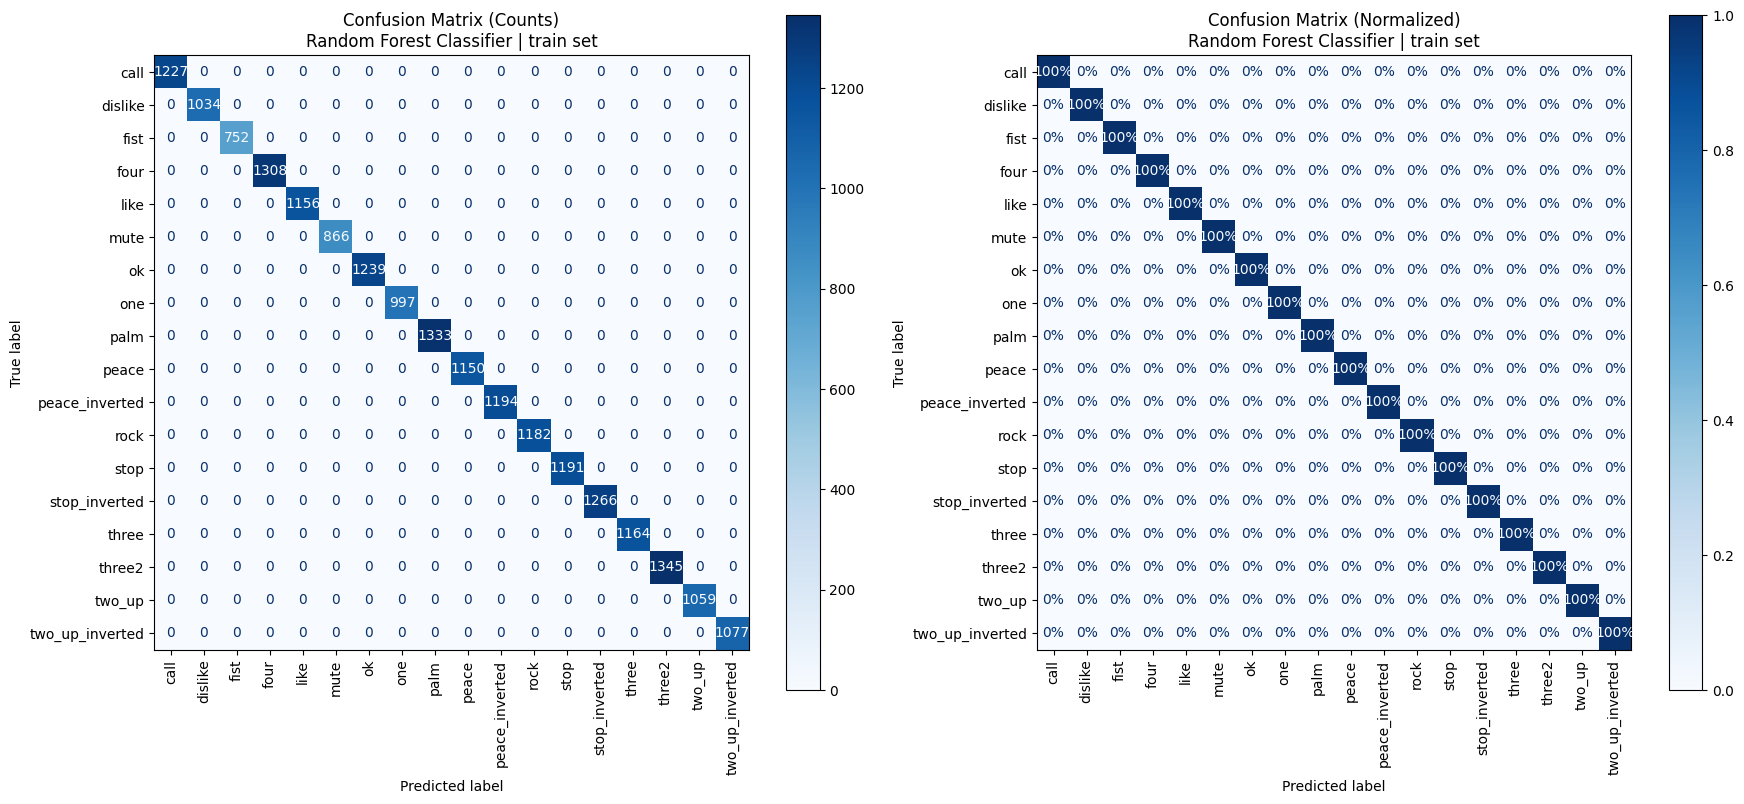

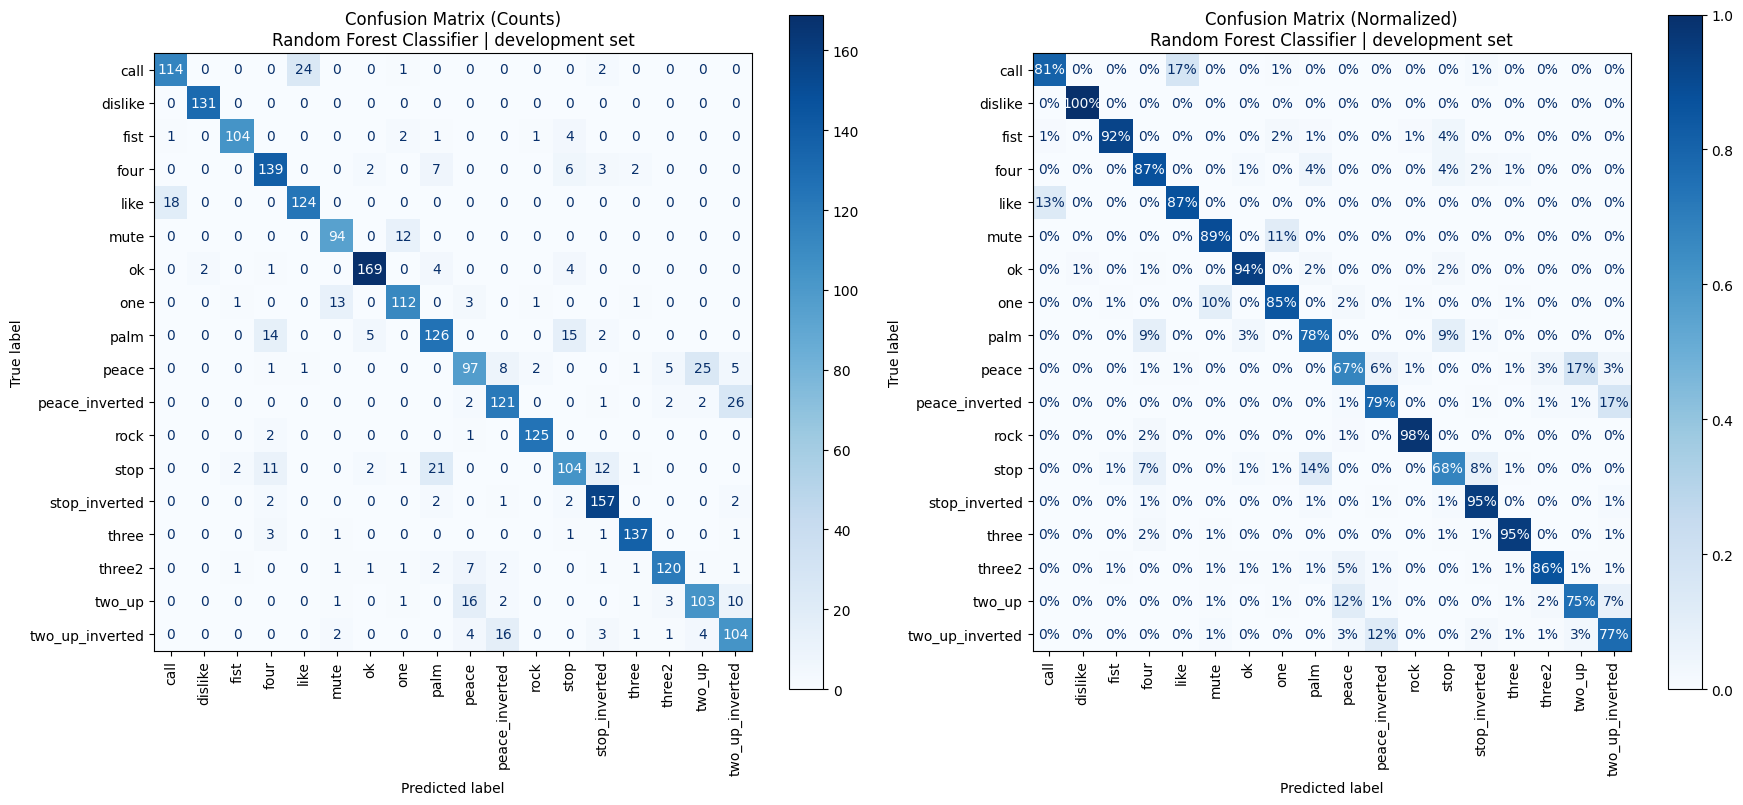

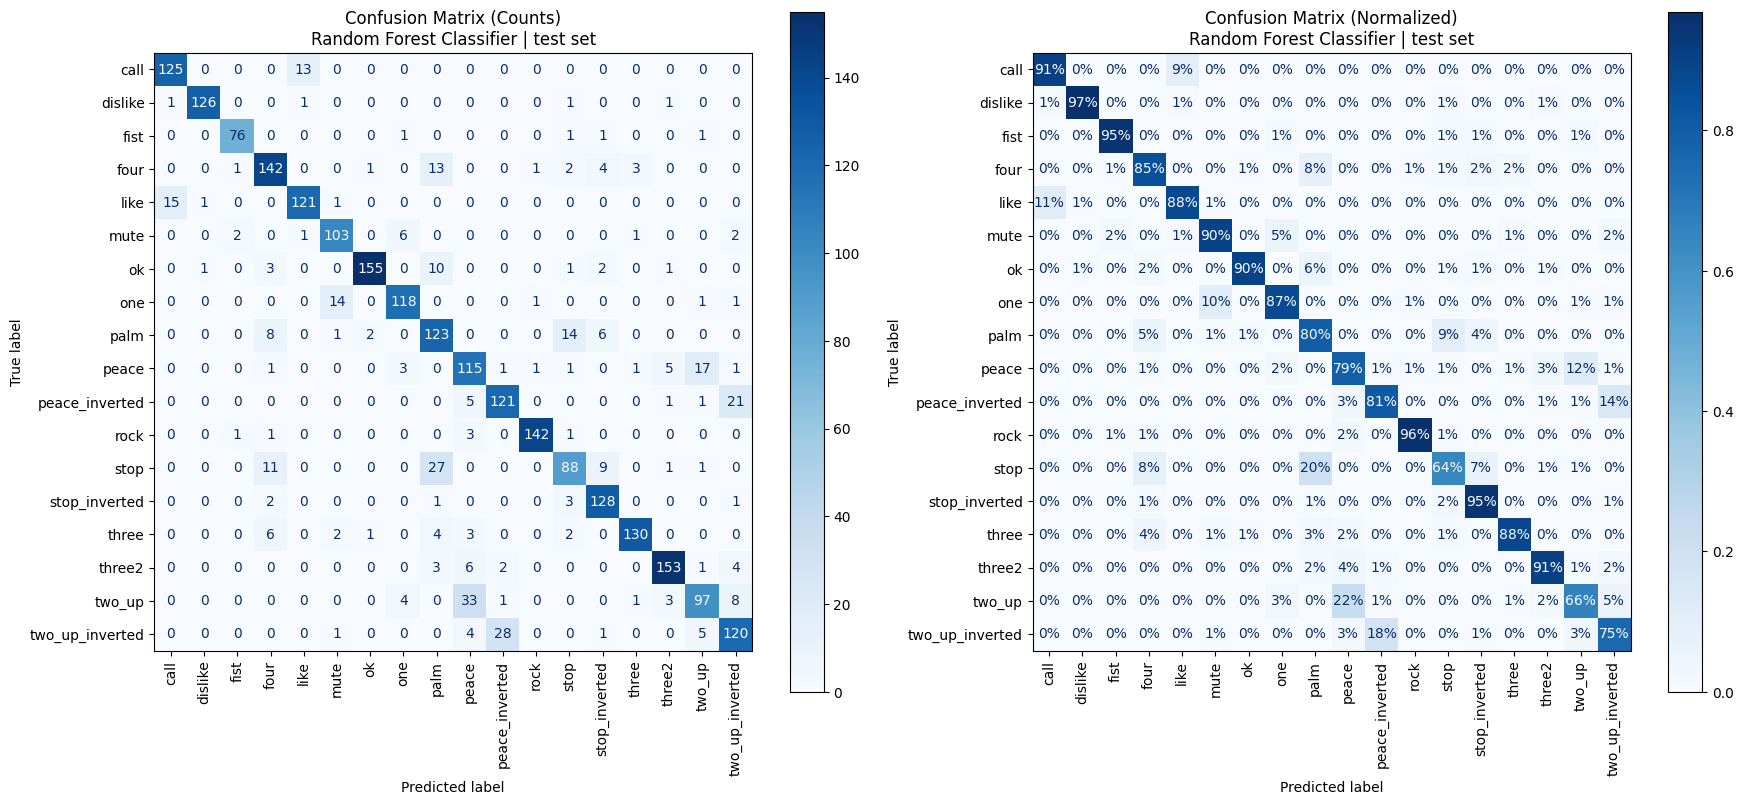

In [9]:
rf_trainer.plot_confusion_matrix(rf_model_name, le, "train set")

rf_trainer.plot_confusion_matrix(rf_model_name, le, "development set")

rf_trainer.plot_confusion_matrix(rf_model_name, le, "test set")

In [10]:
# get model
rf_clf = rf_trainer.get_model(model_name=rf_model_name)
rf_clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

d:\ITI Materials\Projects\Hand Marks Detection\Hands_Marks_Detection_main\hand_gest_env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


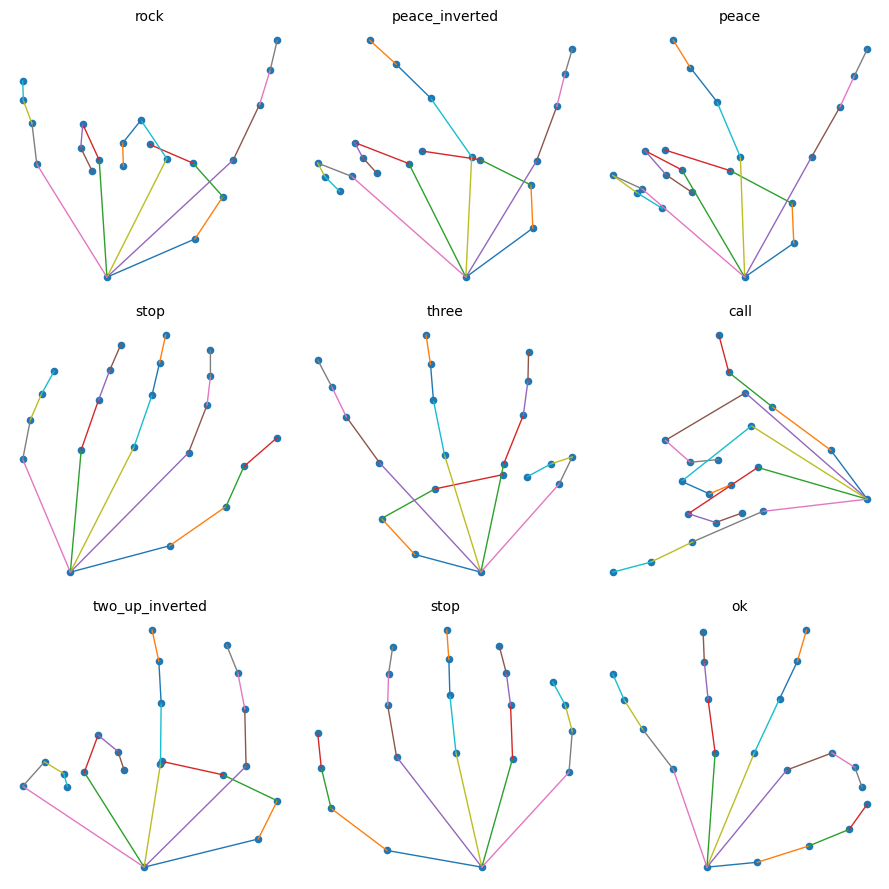

In [11]:
plot_correct_landmarks(
    rf_clf,
    X_dev,
    y_dev_np,
    le,
    n_samples=9
)

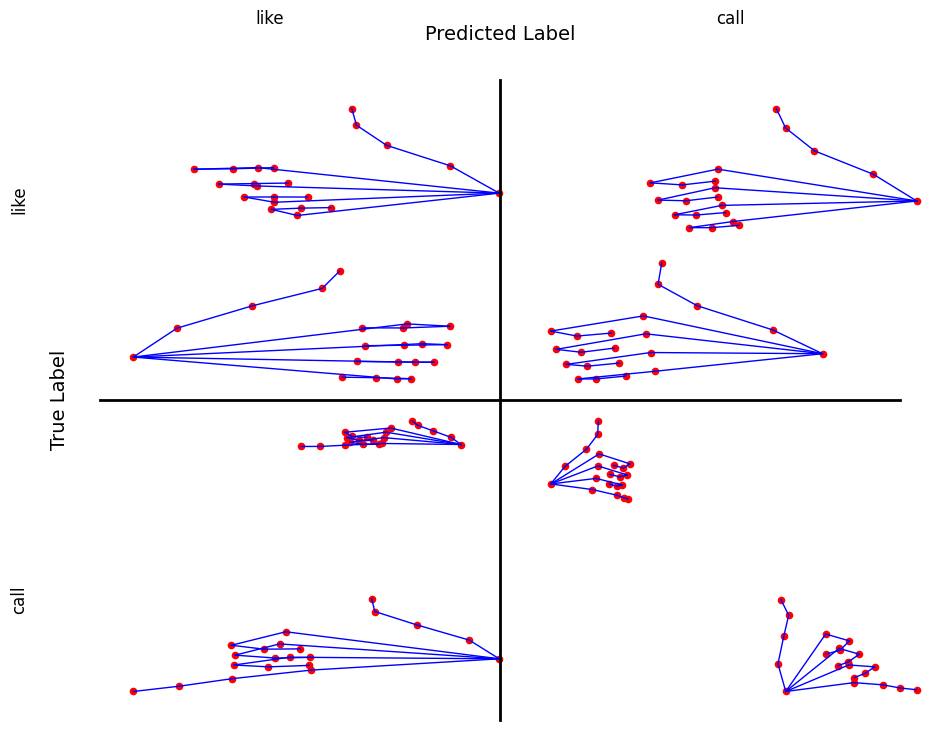

In [12]:
plot_two_class_table(rf_clf, X_dev_np, y_dev_np, le, "like", "call", n_per_cell=2)

## SVM

In [13]:
svm_model_name = "SVM"

# initialize SVM object
SVM_model = SVC(kernel='rbf', C=1, gamma='scale')

# initialize ModelTrainer object
SVM_trainer = ModelTrainer(X_train_np, y_train_np)

# train SVM_trainer object
SVM_trainer.train(SVM_model, svm_model_name)

# evaluate SVM_model on datasets
SVM_trainer.evaluate_and_store(svm_model_name, X_train_np, y_train_np, "train set")
SVM_trainer.evaluate_and_store(svm_model_name, X_dev_np, y_dev_np, "development set")
SVM_trainer.evaluate_and_store(svm_model_name, X_test_np, y_test_np, "test set")

# print out the metrics
SVM_trainer.print_results("train set")
SVM_trainer.print_results("development set")
SVM_trainer.print_results("test set")


📌 SVM on train set
accuracy: 0.8265
precision: 0.8365
recall: 0.8265
f1_score: 0.8271

📌 SVM on development set
accuracy: 0.8111
precision: 0.8234
recall: 0.8118
f1_score: 0.8113

📌 SVM on test set
accuracy: 0.8037
precision: 0.8177
recall: 0.8074
f1_score: 0.8071


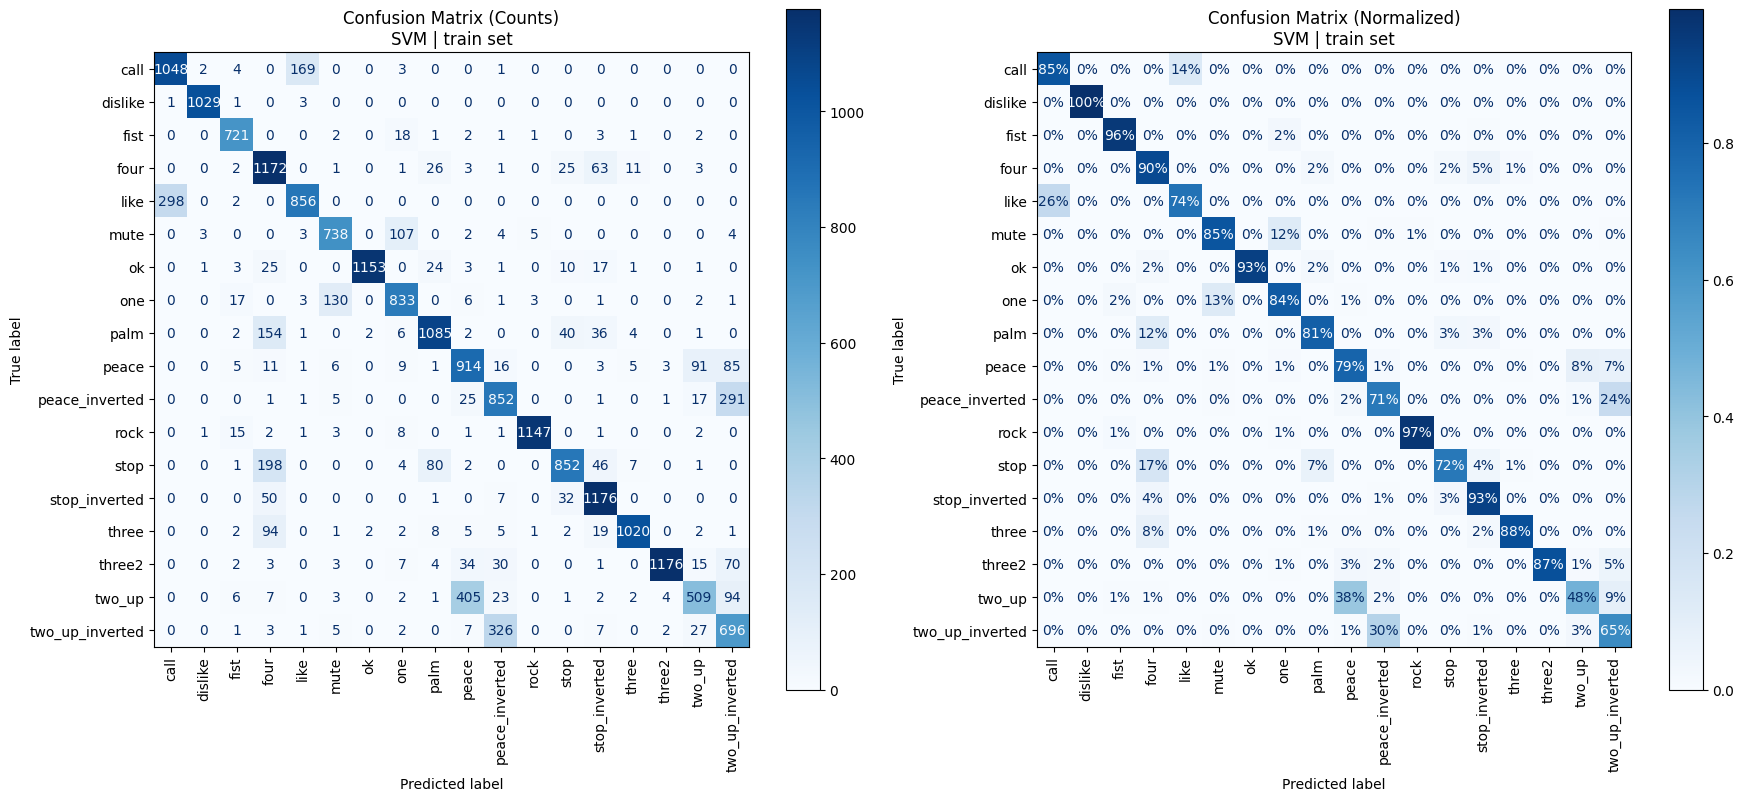

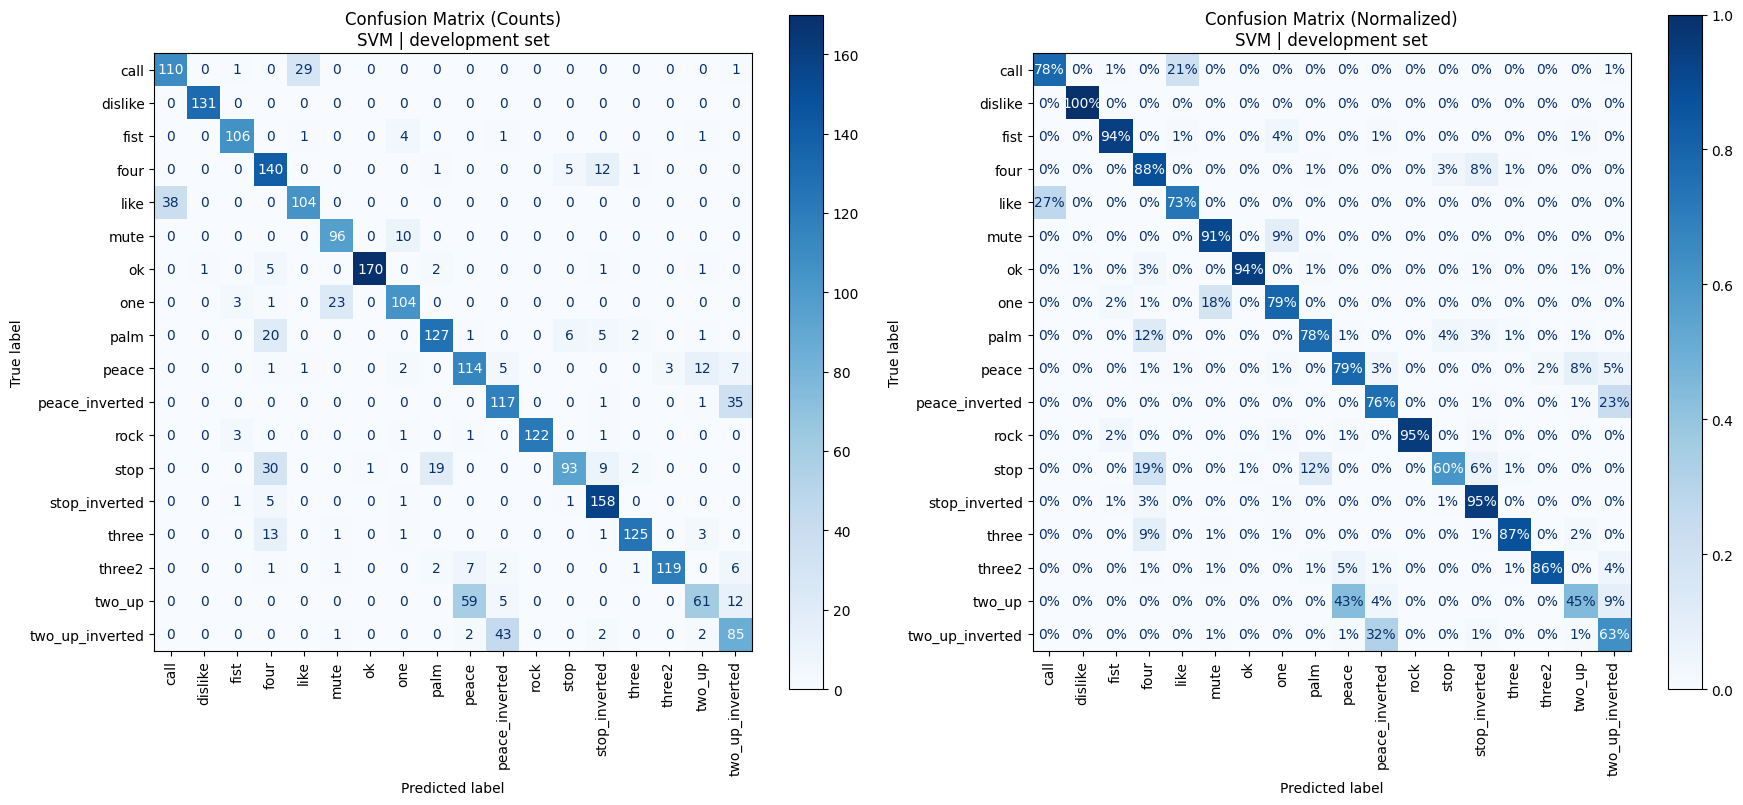

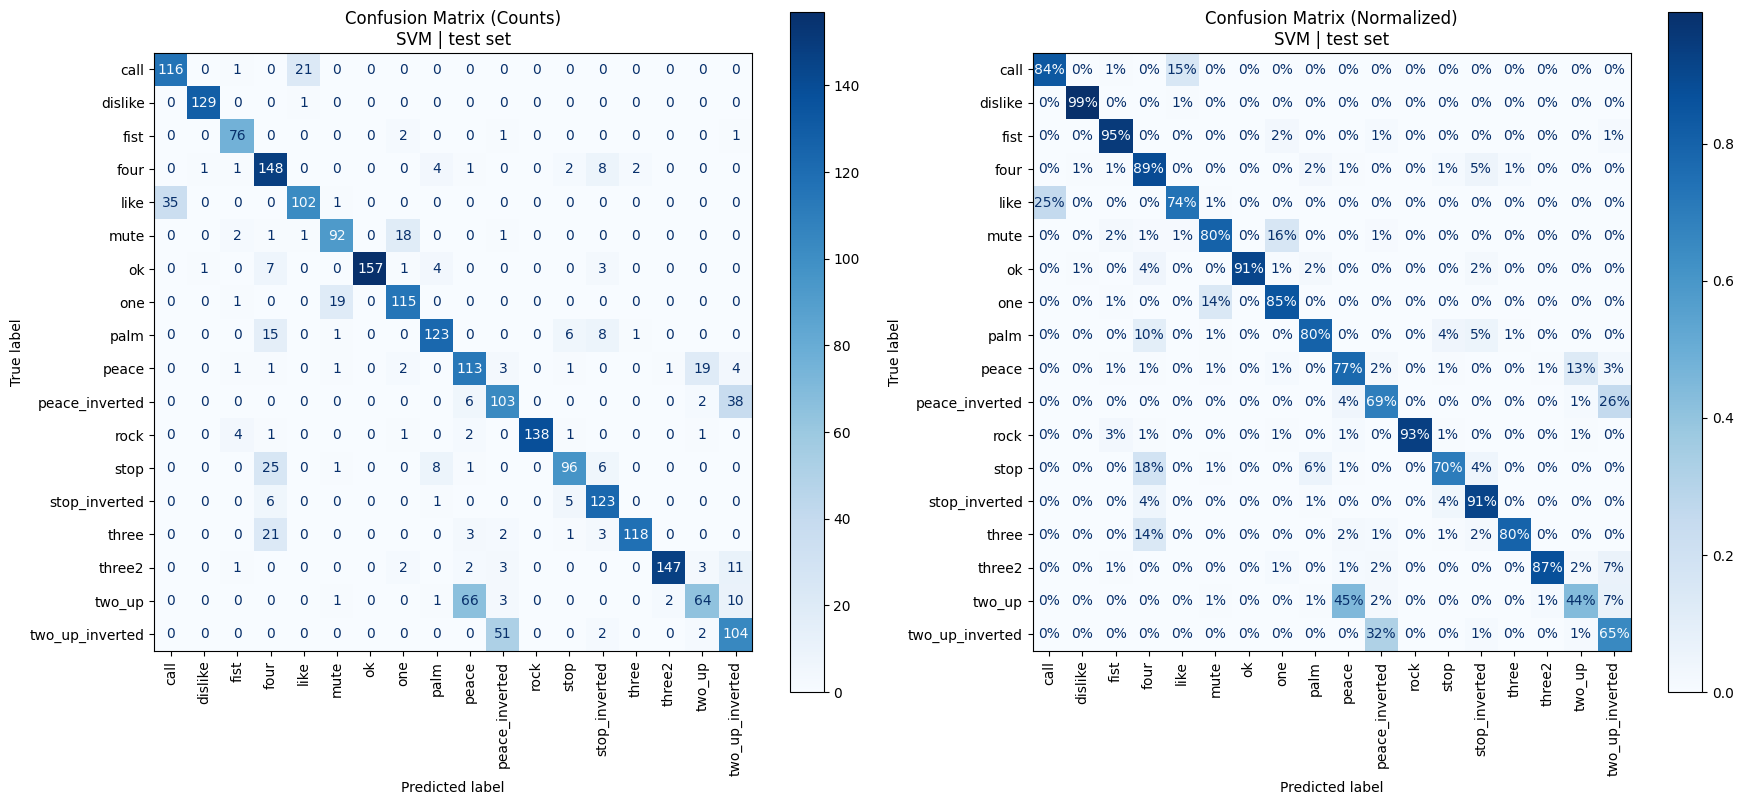

In [14]:
SVM_trainer.plot_confusion_matrix(svm_model_name, le, "train set")

SVM_trainer.plot_confusion_matrix(svm_model_name, le, "development set")

SVM_trainer.plot_confusion_matrix(svm_model_name, le, "test set")

In [15]:
# get svm model
svm_clf = SVM_trainer.get_model(model_name=svm_model_name)
svm_clf

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


d:\ITI Materials\Projects\Hand Marks Detection\Hands_Marks_Detection_main\hand_gest_env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


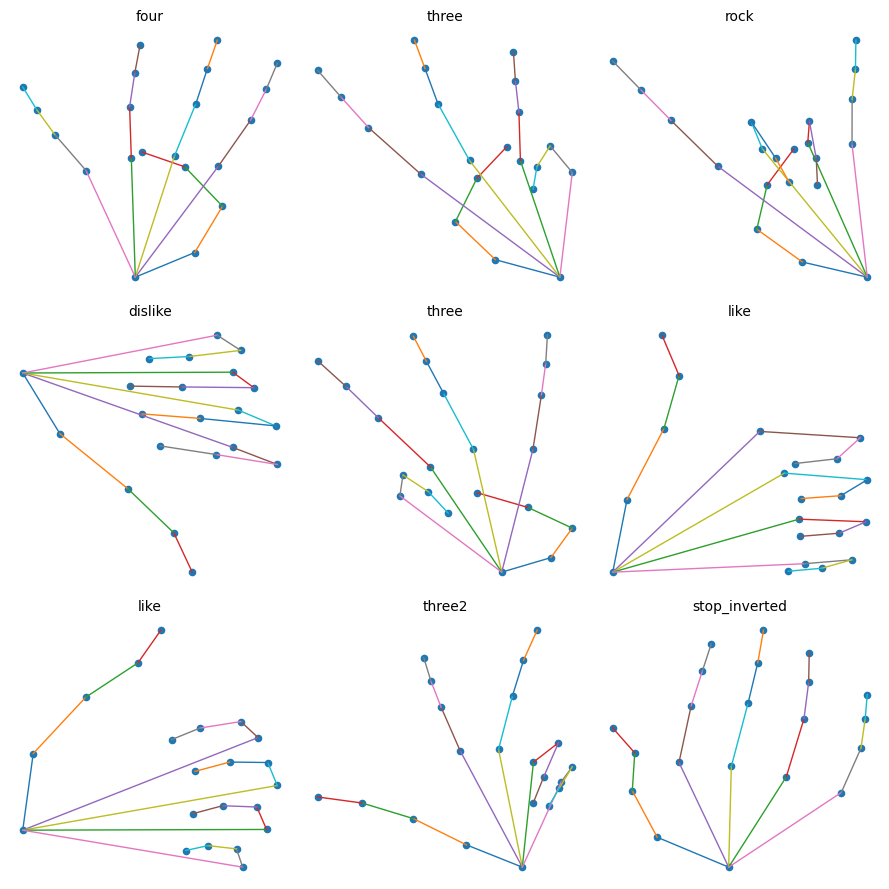

In [16]:
# plot correctly predicted images
plot_correct_landmarks(
    svm_clf,
    X_dev,
    y_dev,
    le,
    n_samples=9
)

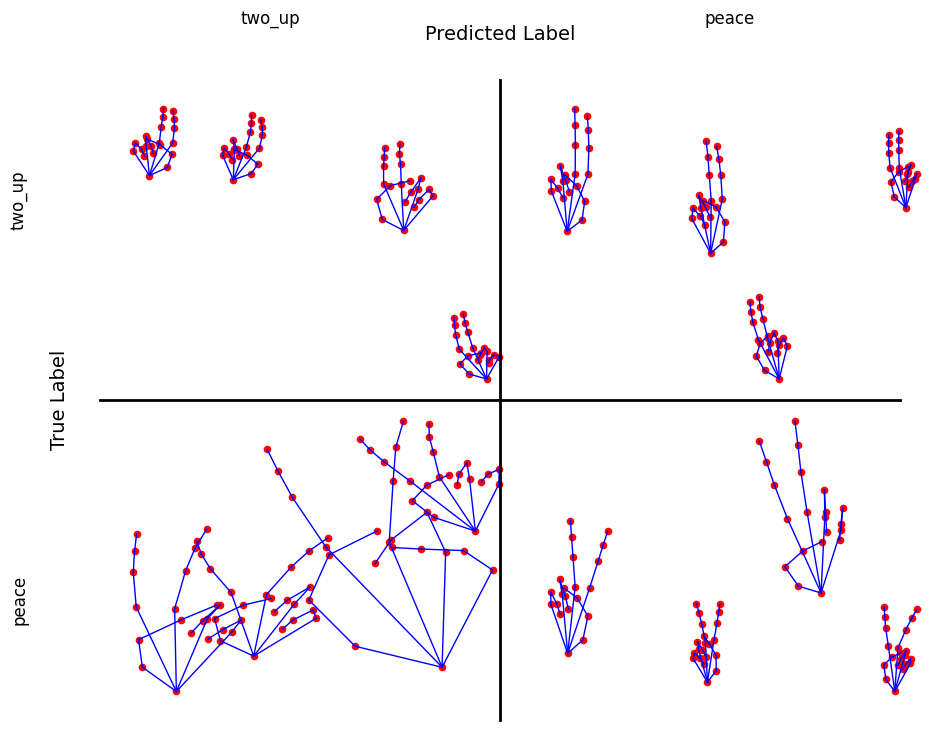

In [17]:
plot_two_class_table(svm_clf, X_dev_np, y_dev_np, le, "two_up", "peace", n_per_cell=4)

## DecisionTreeClassifier

In [18]:
dt_model_name = "Decision Tree Classifier"

# initialize RandomForestClassifier object
dt_model = DecisionTreeClassifier(random_state=0)

# initialize ModelTrainer object
dt_trainer = ModelTrainer(X_train_np, y_train_np)

# train dt_trainer object
dt_trainer.train(dt_model, dt_model_name)

# evaluate dt_model on datasets
dt_trainer.evaluate_and_store(dt_model_name, X_train_np, y_train_np, "train set")
dt_trainer.evaluate_and_store(dt_model_name, X_dev_np, y_dev_np, "development set")
dt_trainer.evaluate_and_store(dt_model_name, X_test_np, y_test_np, "test set")

# print out the metrics
dt_trainer.print_results("train set")
dt_trainer.print_results("development set")
dt_trainer.print_results("test set")


📌 DECISION TREE CLASSIFIER on train set
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1_score: 1.0000

📌 DECISION TREE CLASSIFIER on development set
accuracy: 0.7121
precision: 0.7214
recall: 0.7186
f1_score: 0.7195

📌 DECISION TREE CLASSIFIER on test set
accuracy: 0.7037
precision: 0.7133
recall: 0.7113
f1_score: 0.7115


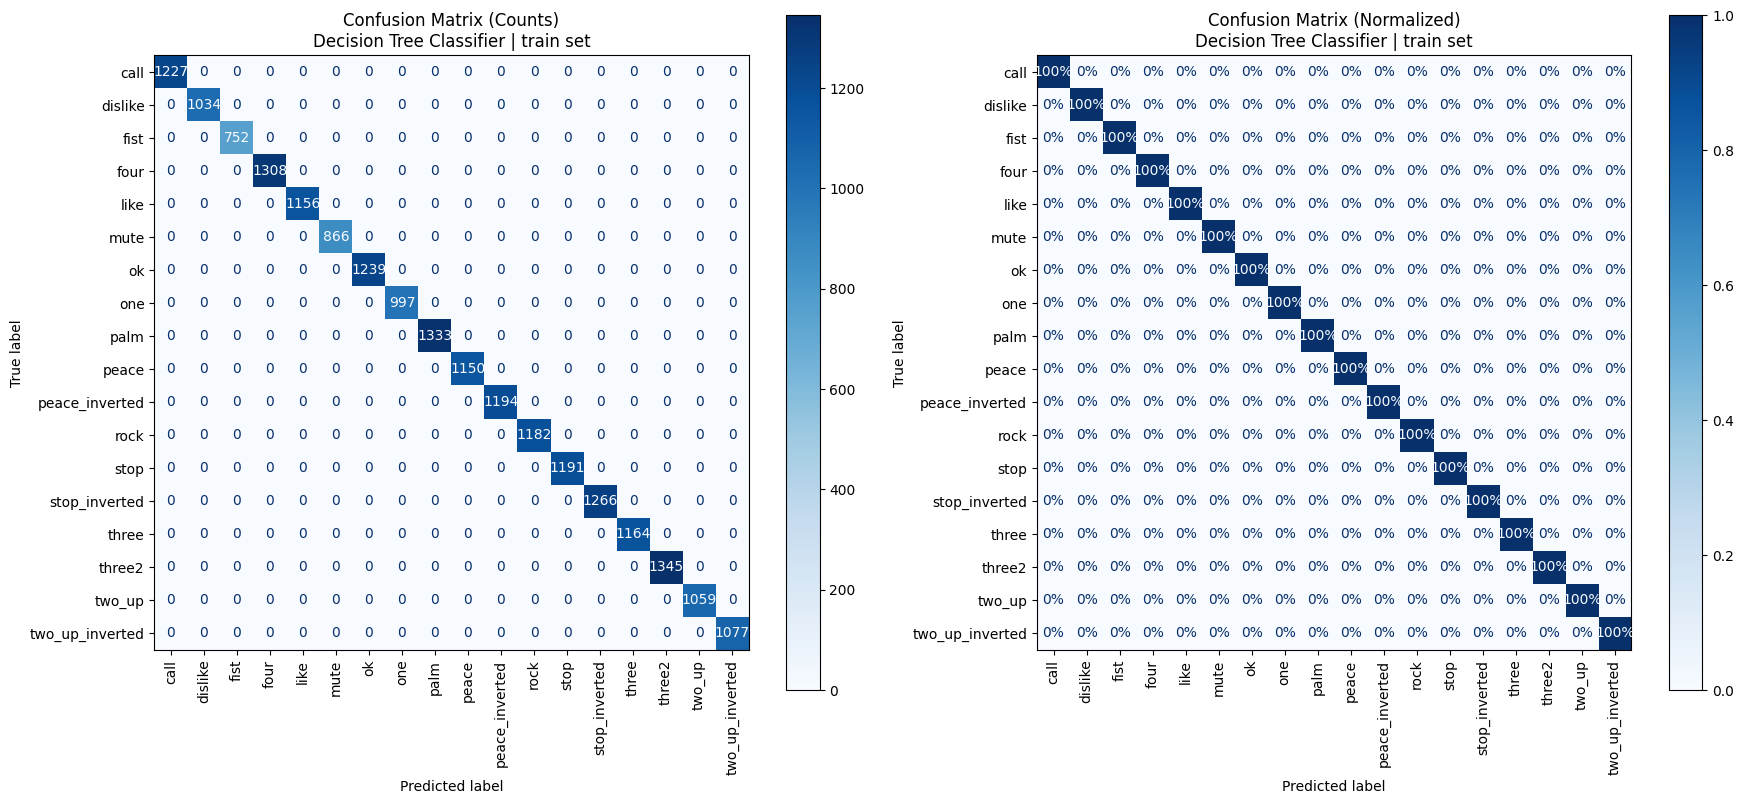

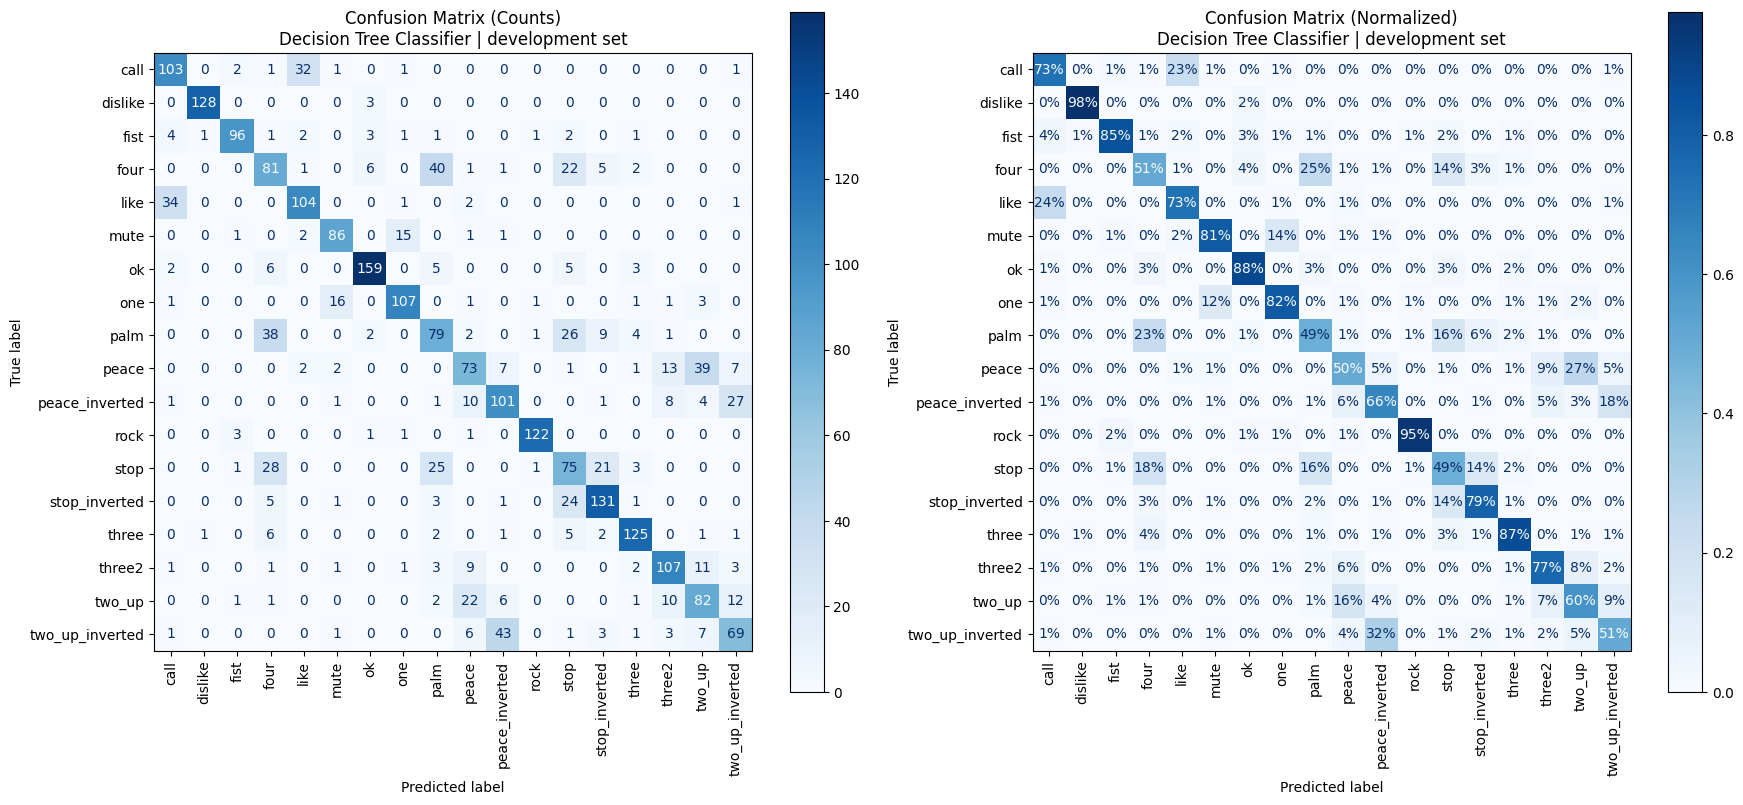

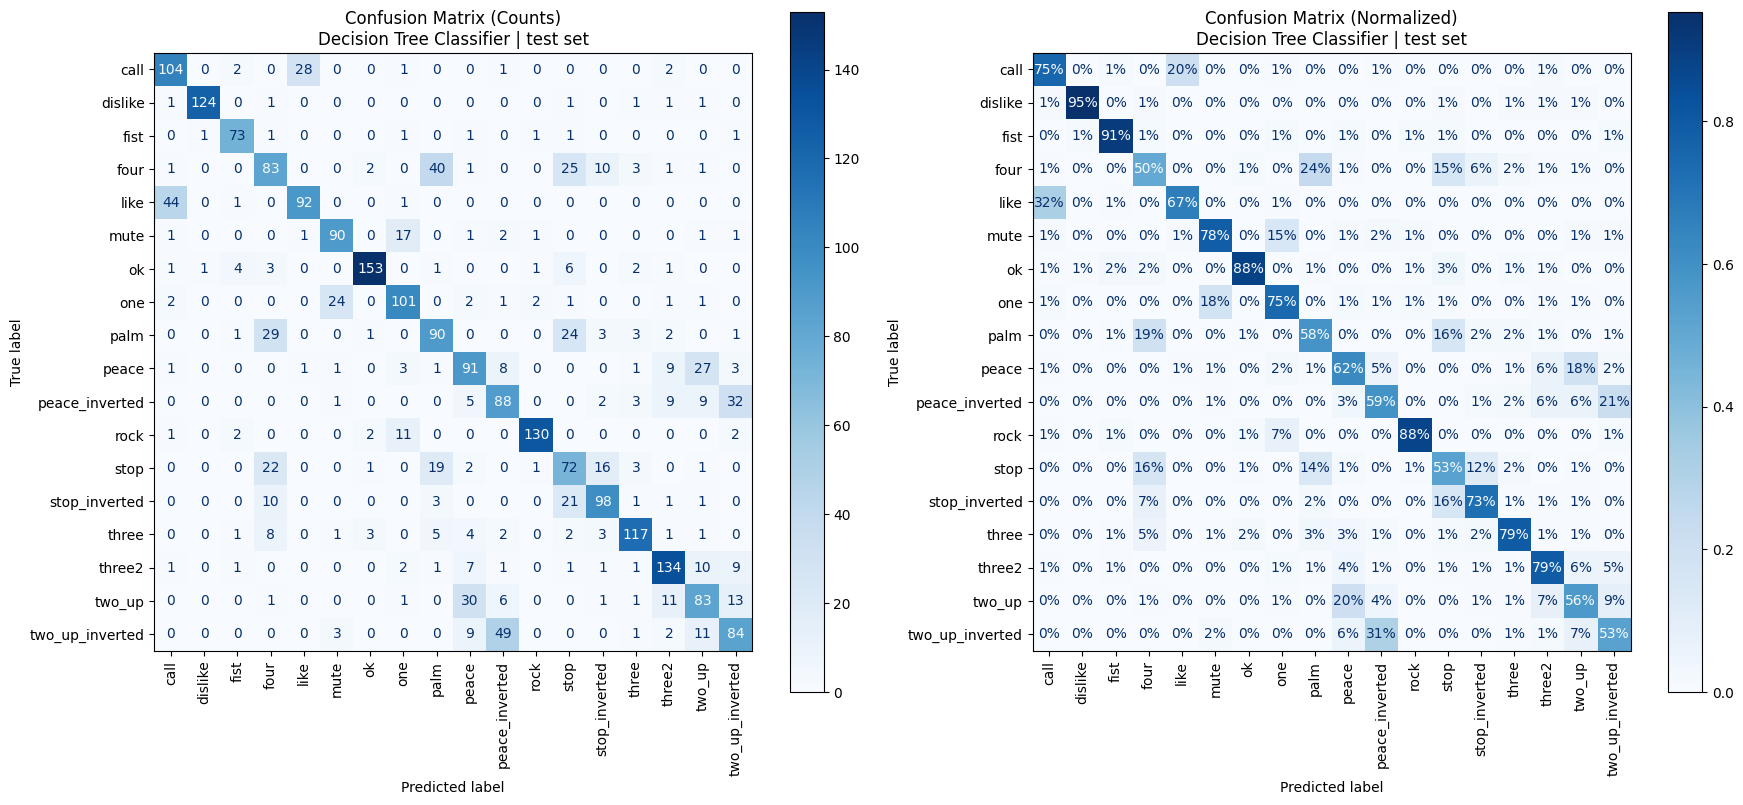

In [19]:
dt_trainer.plot_confusion_matrix(dt_model_name, le, "train set")

dt_trainer.plot_confusion_matrix(dt_model_name, le, "development set")

dt_trainer.plot_confusion_matrix(dt_model_name, le, "test set")

In [20]:
# get decision tree model
dt_clf = dt_trainer.get_model(model_name=dt_model_name)
dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

d:\ITI Materials\Projects\Hand Marks Detection\Hands_Marks_Detection_main\hand_gest_env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


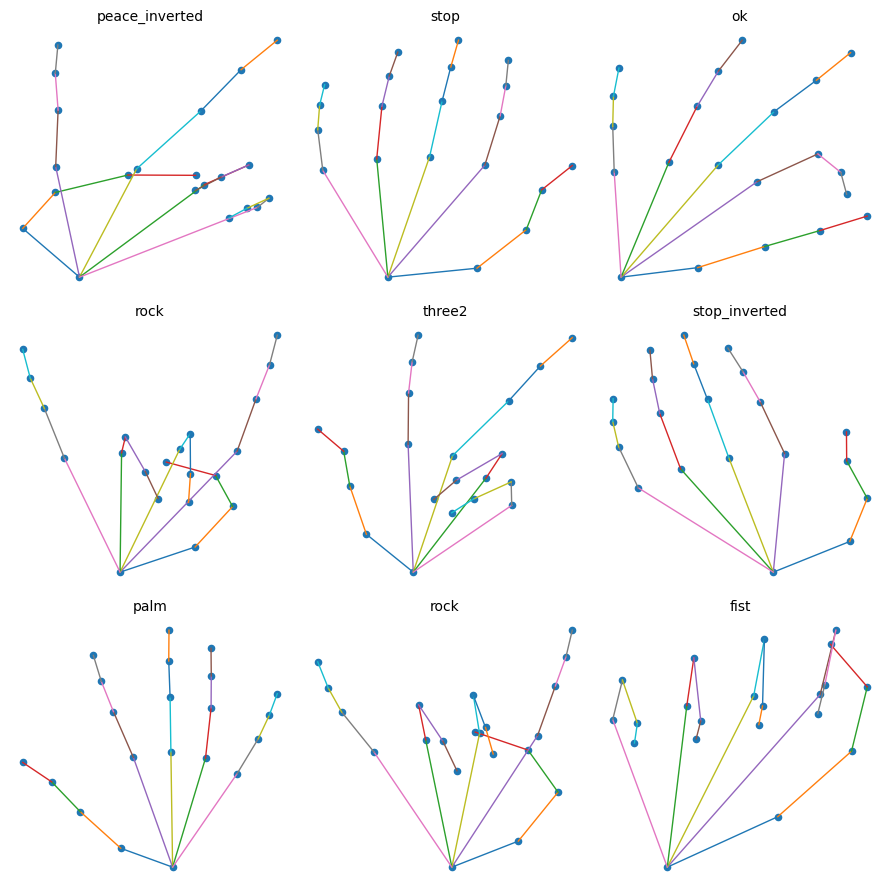

In [21]:
plot_correct_landmarks(
    dt_clf,
    X_dev,
    y_dev_np,
    le,
    n_samples=9
)

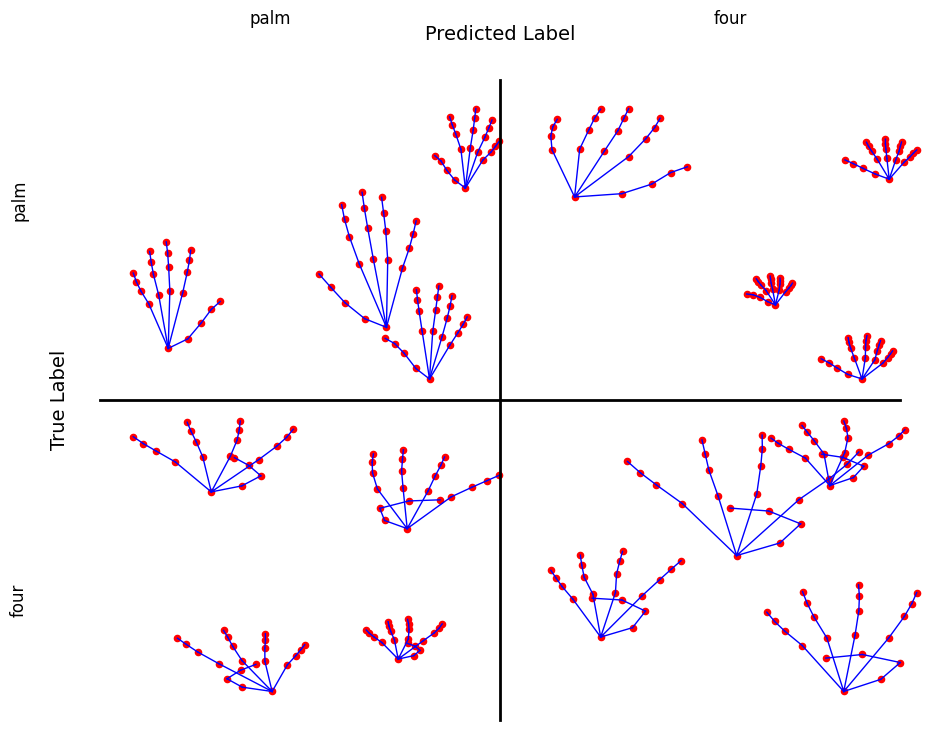

In [22]:
plot_two_class_table(dt_clf, X_dev_np, y_dev_np, le, "palm", "four", n_per_cell=4)

## K-Fold GridSearch 

In [23]:
# model parameters declaration
model_params = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params":{
            "n_estimators": [80, 100, 120],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    },

    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1, 5, 10],
            "kernel": ["linear", "rbf"]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 5, 10, 20],
        }
    }
}